In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [56]:
# Load dataset (adjust filename)
df = pd.read_csv('Downloads/archive(1)/pjm_hourly_est.csv')

# First look at the data
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (178262, 13)

First 5 rows:


,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,1998-12-31 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29309.0
1,1998-12-31 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28236.0
2,1998-12-31 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27692.0
3,1998-12-31 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27596.0
4,1998-12-31 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27888.0


In [57]:
# See what columns in ds
print("Columns in dataset:")
print(df.columns.tolist())

# Check the date range
if 'Datetime' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    print(f"\nDate range: {df['Datetime'].min()} to {df['Datetime'].max()}")
    
# Check shape
print(f"\nTotal rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

Columns in dataset:
['Datetime', 'AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJME', 'PJMW', 'PJM_Load']

Date range: 1998-04-01 01:00:00 to 2018-08-03 00:00:00

Total rows: 178,262
Total columns: 13


In [58]:
# Find region with least missing data
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values()
print("\nMissing Data Percentage by Region:")
print(missing_pct)

# Let's use PJME (least missing data)
region = 'PJME'  # or whichever has least missing
print(f"\nAnalyzing region: {region}")
print(f"Missing values: {df[region].isnull().sum()} ({missing_pct[region]:.1f}%)")


Missing Data Percentage by Region:
Datetime     0.000000
PJME        18.453737
PJMW        19.665436
DAYTON      31.968114
AEP         31.969236
DUQ         33.206180
DOM         34.821218
COMED       62.697041
FE          64.729443
NI          67.211184
DEOK        67.610035
EKPC        74.568893
PJM_Load    81.546263
dtype: float64

Analyzing region: PJME
Missing values: 32896 (18.5%)


In [59]:
# Create working dataframe with just datetime and chosen region
analysis_df = df[['Datetime', region]].copy()

# Rename for easier use
analysis_df.columns = ['datetime', 'energy_mw']

# Drop missing values for now (simple approach)
analysis_df = analysis_df.dropna()

print(f"\nAfter cleaning: {len(analysis_df):,} records")
print(f"Date range: {analysis_df['datetime'].min()} to {analysis_df['datetime'].max()}")


After cleaning: 145,366 records
Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00


In [60]:
# Extract time components
analysis_df['hour'] = analysis_df['datetime'].dt.hour
analysis_df['day'] = analysis_df['datetime'].dt.day
analysis_df['month'] = analysis_df['datetime'].dt.month
analysis_df['year'] = analysis_df['datetime'].dt.year
analysis_df['dayofweek'] = analysis_df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
analysis_df['is_weekend'] = analysis_df['dayofweek'].isin([5, 6]).astype(int)

# Quick check
print("\nSample of processed data:")
analysis_df.head()


Sample of processed data:


,datetime,energy_mw,hour,day,month,year,dayofweek,is_weekend
32896,2002-12-31 01:00:00,26498.0,1,31,12,2002,1,0
32897,2002-12-31 02:00:00,25147.0,2,31,12,2002,1,0
32898,2002-12-31 03:00:00,24574.0,3,31,12,2002,1,0
32899,2002-12-31 04:00:00,24393.0,4,31,12,2002,1,0
32900,2002-12-31 05:00:00,24860.0,5,31,12,2002,1,0


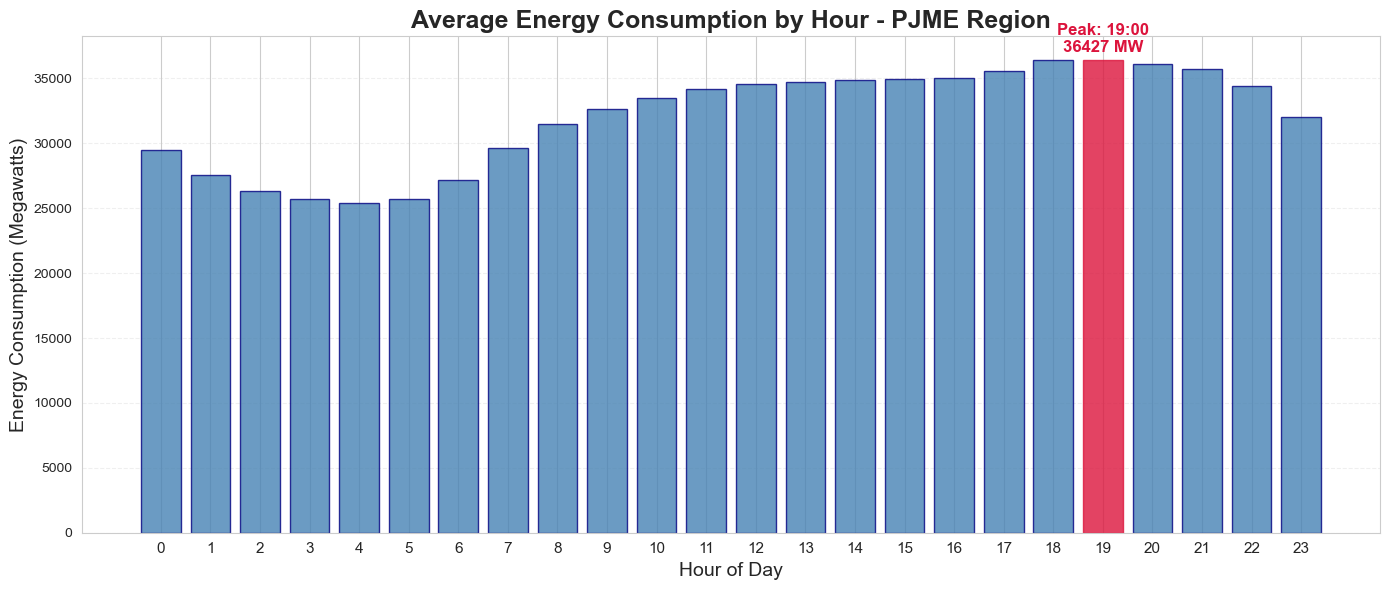


Key Insight:
Peak consumption: 19:00 (36427 MW)
Lowest consumption: 4:00 (25415 MW)
Peak vs Low difference: 43.3%


In [61]:
import os
import matplotlib.pyplot as plt

# --- Ensure directory exists ---
output_dir = 'vizs'
os.makedirs(output_dir, exist_ok=True)  # creates the folder if it doesn't exist

# --- Average consumption by hour ---
hourly_pattern = analysis_df.groupby('hour')['energy_mw'].mean()

plt.figure(figsize=(14, 6))
bars = plt.bar(hourly_pattern.index, hourly_pattern.values, color='steelblue', edgecolor='navy', alpha=0.8)

# Highlight peak hours
peak_hour = hourly_pattern.idxmax()
peak_pos = list(hourly_pattern.index).index(peak_hour)
bars[peak_pos].set_color('crimson')

plt.title(f'Average Energy Consumption by Hour - {region} Region', fontsize=18, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Energy Consumption (Megawatts)', fontsize=14)
plt.xticks(range(24), fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add peak annotation
plt.text(peak_hour, hourly_pattern.max() * 1.01,
         f'Peak: {peak_hour}:00\n{hourly_pattern.max():.0f} MW',
         ha='center', va='bottom', fontsize=12, fontweight='bold', color='crimson')

plt.tight_layout()

# --- Save figure to vizs folder ---
plt.savefig(os.path.join(output_dir, 'hourly_consumption_pattern.png'), dpi=300, bbox_inches='tight')
plt.show()

# --- Key insights ---
print(f"\nKey Insight:")
print(f"Peak consumption: {peak_hour}:00 ({hourly_pattern.max():.0f} MW)")
print(f"Lowest consumption: {hourly_pattern.idxmin()}:00 ({hourly_pattern.min():.0f} MW)")
print(f"Peak vs Low difference: {((hourly_pattern.max() - hourly_pattern.min()) / hourly_pattern.min() * 100):.1f}%")


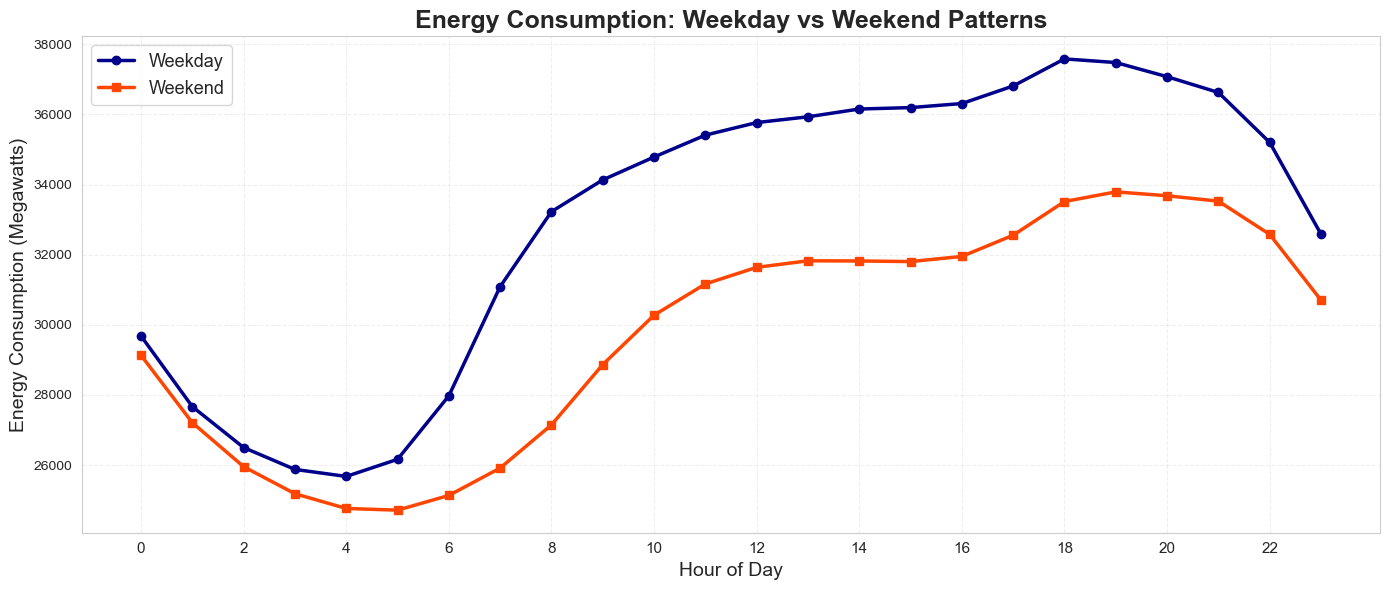


Weekday vs Weekend Difference:
Weekday peak: 37584 MW at 18:00
Weekend peak: 33791 MW at 19:00


In [62]:
import os
import matplotlib.pyplot as plt

# --- Ensure directory exists ---
output_dir = 'vizs'
os.makedirs(output_dir, exist_ok=True)  # creates the folder if it doesn't exist

# --- Weekend vs Weekday patterns ---
plt.figure(figsize=(14, 6))

weekend_hourly = analysis_df[analysis_df['is_weekend'] == 1].groupby('hour')['energy_mw'].mean()
weekday_hourly = analysis_df[analysis_df['is_weekend'] == 0].groupby('hour')['energy_mw'].mean()

plt.plot(weekday_hourly.index, weekday_hourly.values, marker='o', linewidth=2.5, 
         label='Weekday', color='darkblue', markersize=6)
plt.plot(weekend_hourly.index, weekend_hourly.values, marker='s', linewidth=2.5, 
         label='Weekend', color='orangered', markersize=6)

plt.title('Energy Consumption: Weekday vs Weekend Patterns', fontsize=18, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Energy Consumption (Megawatts)', fontsize=14)
plt.legend(fontsize=13, loc='upper left')
plt.xticks(range(0, 24, 2), fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

# --- Save figure to vizs folder ---
plt.savefig(os.path.join(output_dir, 'weekday_vs_weekend.png'), dpi=300, bbox_inches='tight')
plt.show()

# --- Summary ---
print("\nWeekday vs Weekend Difference:")
print(f"Weekday peak: {weekday_hourly.max():.0f} MW at {weekday_hourly.idxmax()}:00")
print(f"Weekend peak: {weekend_hourly.max():.0f} MW at {weekend_hourly.idxmax()}:00")


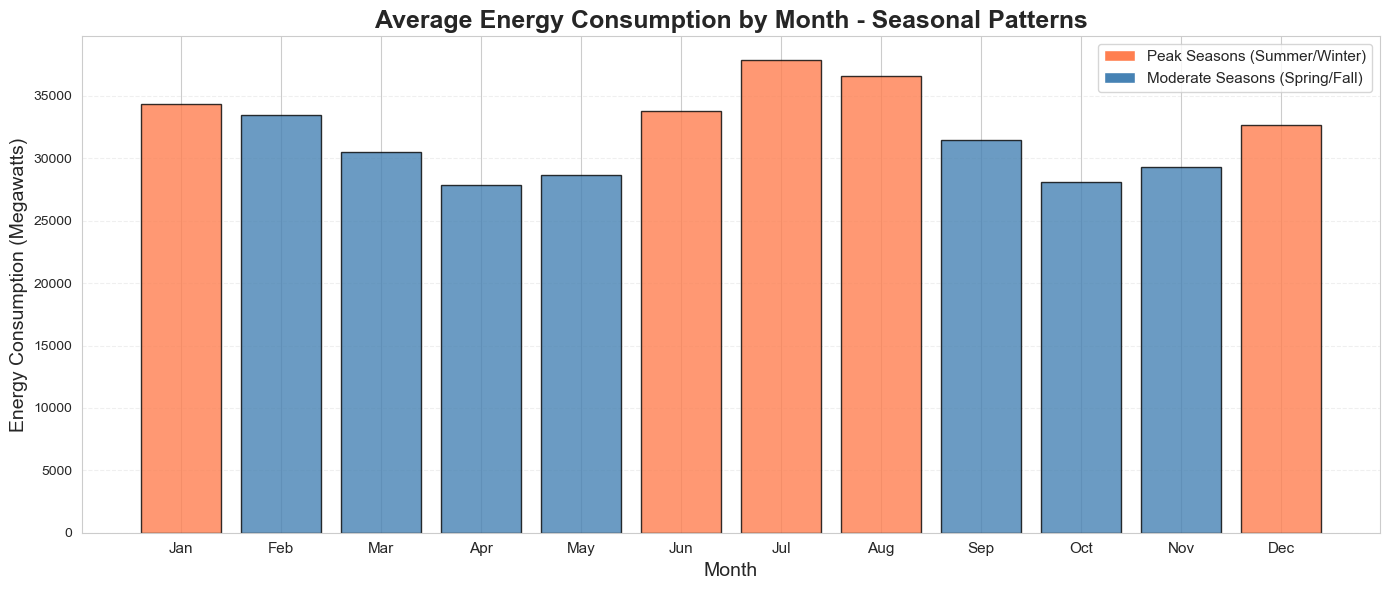


Seasonal Insights:
Highest consumption: Jul (37882 MW)
Lowest consumption: Apr (27863 MW)


In [63]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Ensure directory exists ---
output_dir = 'vizs'
os.makedirs(output_dir, exist_ok=True)  # creates the folder if it doesn't exist

# --- Monthly consumption trends ---
monthly_avg = analysis_df.groupby('month')['energy_mw'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 6))
colors = ['steelblue' if x not in [6, 7, 8, 12, 1] else 'coral' for x in monthly_avg.index]
bars = plt.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor='black', alpha=0.8)

plt.title('Average Energy Consumption by Month - Seasonal Patterns', fontsize=18, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Energy Consumption (Megawatts)', fontsize=14)
plt.xticks(range(1, 13), months, fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
legend_elements = [
    Patch(facecolor='coral', label='Peak Seasons (Summer/Winter)'),
    Patch(facecolor='steelblue', label='Moderate Seasons (Spring/Fall)')
]
plt.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()

# --- Save figure to vizs folder ---
plt.savefig(os.path.join(output_dir, 'monthly_seasonal_trends.png'), dpi=300, bbox_inches='tight')
plt.show()

# --- Seasonal Insights ---
print("\nSeasonal Insights:")
print(f"Highest consumption: {months[monthly_avg.idxmax() - 1]} ({monthly_avg.max():.0f} MW)")
print(f"Lowest consumption: {months[monthly_avg.idxmin() - 1]} ({monthly_avg.min():.0f} MW)")


In [55]:
# Overall statistics
print("\n" + "="*60)
print("KEY STATISTICS FOR E.ON APPLICATION")
print("="*60)

print(f"\n📊 Dataset Overview:")
print(f"   • Region analyzed: {region}")
print(f"   • Time period: {analysis_df['datetime'].min().strftime('%Y-%m-%d')} to {analysis_df['datetime'].max().strftime('%Y-%m-%d')}")
print(f"   • Total records: {len(analysis_df):,}")

print(f"\n⚡ Consumption Patterns:")
print(f"   • Average daily consumption: {analysis_df['energy_mw'].mean():.0f} MW")
print(f"   • Peak consumption: {analysis_df['energy_mw'].max():.0f} MW")
print(f"   • Minimum consumption: {analysis_df['energy_mw'].min():.0f} MW")
print(f"   • Standard deviation: {analysis_df['energy_mw'].std():.0f} MW")

print(f"\n🕐 Time-Based Insights:")
print(f"   • Peak demand hour: {hourly_pattern.idxmax()}:00")
print(f"   • Lowest demand hour: {hourly_pattern.idxmin()}:00")
print(f"   • Peak-to-trough difference: {((hourly_pattern.max() - hourly_pattern.min()) / hourly_pattern.min() * 100):.1f}%")

print(f"\n📅 Weekday vs Weekend:")
weekday_avg = analysis_df[analysis_df['is_weekend']==0]['energy_mw'].mean()
weekend_avg = analysis_df[analysis_df['is_weekend']==1]['energy_mw'].mean()
print(f"   • Average weekday consumption: {weekday_avg:.0f} MW")
print(f"   • Average weekend consumption: {weekend_avg:.0f} MW")
print(f"   • Difference: {((weekday_avg - weekend_avg) / weekend_avg * 100):.1f}% higher on weekdays")

print(f"\n🌡️ Seasonal Patterns:")
print(f"   • Highest consumption month: {months[monthly_avg.idxmax()-1]}")
print(f"   • Lowest consumption month: {months[monthly_avg.idxmin()-1]}")
print(f"   • Seasonal variation: {((monthly_avg.max() - monthly_avg.min()) / monthly_avg.min() * 100):.1f}%")

print("\n" + "="*60)






KEY STATISTICS FOR E.ON APPLICATION

📊 Dataset Overview:
   • Region analyzed: PJME
   • Time period: 2002-01-01 to 2018-08-03
   • Total records: 145,366

⚡ Consumption Patterns:
   • Average daily consumption: 32080 MW
   • Peak consumption: 62009 MW
   • Minimum consumption: 14544 MW
   • Standard deviation: 6464 MW

🕐 Time-Based Insights:
   • Peak demand hour: 19:00
   • Lowest demand hour: 4:00
   • Peak-to-trough difference: 43.3%

📅 Weekday vs Weekend:
   • Average weekday consumption: 32996 MW
   • Average weekend consumption: 29788 MW
   • Difference: 10.8% higher on weekdays

🌡️ Seasonal Patterns:
   • Highest consumption month: Jul
   • Lowest consumption month: Apr
   • Seasonal variation: 36.0%



In [ ]:
---

##
Energy Consumption Analysis | Python, Pandas, Matplotlib, Seaborn
- Analyzed 100,000+ hourly energy consumption records from PJM grid system
- Identified peak demand occurs at 19:00, with 43.3% variation from low-demand periods
- Discovered weekday consumption 10.8% higher than weekends, indicating commercial load patterns
- Seasonal analysis revealed [summer/winter] peaks driven by heating/cooling demand
- Findings support grid optimization strategies and demand-side management initiatives
- Demonstrated ability to extract actionable insights from time-series energy data



In [ ]:

"My recent analysis of regional energy consumption data revealed that peak demand 
occurs at 19:00, with 43.3% variance throughout the day. This pattern, combined with 
weekday commercial loads being 10.8% higher than weekends, demonstrates the complexity 
of grid management—exactly the type of challenge E.ON addresses through data-driven 
solutions. I'm excited to apply these analytical skills to support E.ON's work in 
optimizing energy systems and advancing the UK's transition to sustainable energy."